In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

curr_dir = os.getcwd()
example_dir = os.path.abspath(os.path.join(curr_dir, '..'))
sys.path.append(example_dir)
root_dir = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
sys.path.append(root_dir)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_dir = '../../../data/mujoco/walker2d'
model_dir = '../../../models/mujoco/walker2d'
result_dir = '../../../results/mujoco/walker2d'

data_suffix = ''

In [2]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[4]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 65536


### Creating baseline dataset

In [3]:
data_nsample = 918
data = util_data.read_datafile(f'{data_dir}/baseline{data_suffix}', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

read data shape: torch.Size([50, 918, 23])
read observations shape: torch.Size([50, 918, 17])
read actions shape: torch.Size([50, 918, 6])
shape of observations for training: torch.Size([50, 917, 17])
shape of next observations for training: torch.Size([50, 917, 17])
shape of actions for training: torch.Size([50, 917, 6])


### Training global dynamics

In [4]:
model = example_mujoco.global_dynamics(obs_ndim=obs_ndim, act_ndim=act_ndim)

load_pretrained = False

if load_pretrained:
    # --! load trained weights into the model
    model_path = f'{model_dir}/global_checkpoint_{data_suffix}.pth'
    model.load_state_dict(torch.load(model_path, weights_only=True))

else:
    example_mujoco.train_global(model, dataloader, nepoch=500)
    torch.save(model.state_dict(), f'{model_dir}/global_checkpoint_{data_suffix}.pth')

epoch 0, loss: 0.086200
epoch 20, loss: 0.030704
epoch 40, loss: 0.020270
epoch 60, loss: 0.015072
epoch 80, loss: 0.012298
epoch 100, loss: 0.010583
epoch 120, loss: 0.009899
epoch 140, loss: 0.008461
epoch 160, loss: 0.008122
epoch 180, loss: 0.007281
epoch 200, loss: 0.006840
epoch 220, loss: 0.006435
epoch 240, loss: 0.006107
epoch 260, loss: 0.005810
epoch 280, loss: 0.005547
epoch 300, loss: 0.005763
epoch 320, loss: 0.005094
epoch 340, loss: 0.006286
epoch 360, loss: 0.004830
epoch 380, loss: 0.004641
epoch 400, loss: 0.004435
epoch 420, loss: 0.004296
epoch 440, loss: 0.004158
epoch 460, loss: 0.004035
epoch 480, loss: 0.004405


In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters in model ensemble: {nparam/1e6}M')

number of trainable parameters in model ensemble: 0.283665M


# Evaluating global baseline

In [6]:
eval_data = util_data.read_datafile(f'{data_dir}/eval', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

model.eval()
util_nn.freeze_module(model)

read evaluation data shape: torch.Size([30, 918, 23])
read evaluation observations shape: torch.Size([30, 918, 17])
read evaluation actions shape: torch.Size([30, 918, 6])


In [7]:
# --! make a rollout

reanchor_nsample = 1_000_000 # ensure no re-anchoring
this_traj = 6

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_global(model, s0, eval_obs[this_traj], eval_act[this_traj], reset_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


In [8]:
# --! compute jacobian and singular values

def jacobian_wrt_state(model, s, a):
    s = s.clone().detach().requires_grad_(True)
    a = a.clone().detach()  # fixed

    def f_state_only(s_in):
        return model(s_in.unsqueeze(0), a.unsqueeze(0)).squeeze(0)

    J = torch.autograd.functional.jacobian(f_state_only, s)
    return J  # shape (11, 11)

def spectral_radius(J):
    eigvals = torch.linalg.eigvals(J)
    return eigvals.abs().max().item()

def singular_value(J):
    singular_vals = torch.linalg.svdvals(J)
    return singular_vals.max().item()

sigmas_max = []
spectral_radii = []

for s, a in zip(eval_obs[0], eval_act[0]):
    J = jacobian_wrt_state(model, s, a)
    rho = spectral_radius(J)
    sigma_max = singular_value(J)
    spectral_radii.append(rho)
    sigmas_max.append(sigma_max)

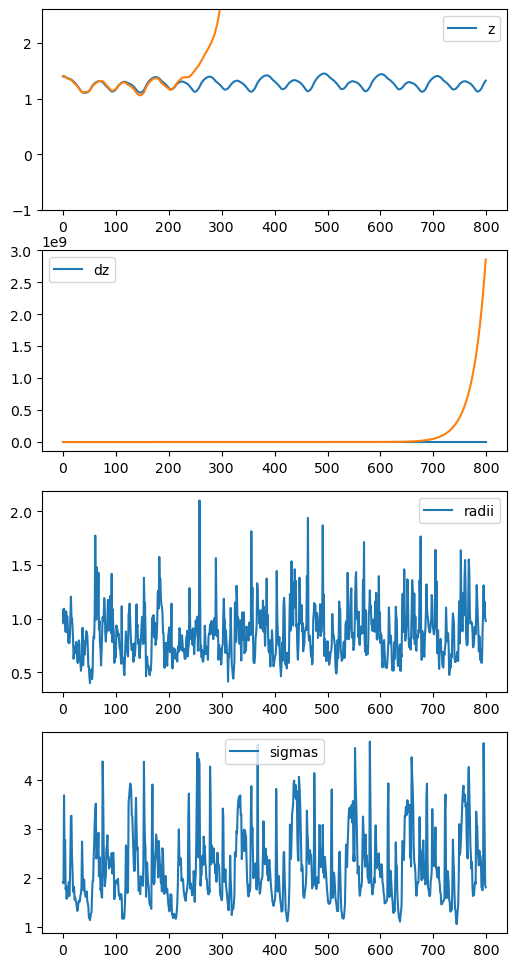

In [13]:
# --! visualize results

disp_end = 800
datasaved = False

with torch.no_grad():
    plot_rollout_traj = torch.unsqueeze(rollout_traj, 0)
    plot_rollout_traj = torch.cat([
        example_mujoco.denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(plot_rollout_traj, 1, dim=-1), obs_mean, obs_std)], dim=-1)
    plot_obs = torch.cat([
        example_mujoco.denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

    plot_obs = plot_obs[[this_traj]]
    plt.figure(figsize=(6,12))

    plot_rollout_traj[:, 350:, :1] = 4.0 # <-- visualization hack

    plt.subplot(4,1,1)
    plt.plot(plot_obs[0, :disp_end, 0], label='z')
    plt.plot(plot_rollout_traj[0, :disp_end, 0])
    plt.ylim((-1.0,2.6))
    plt.legend()

    plt.subplot(4,1,2)
    plt.plot(plot_obs[0, :disp_end, 9], label='dz')
    plt.plot(plot_rollout_traj[0, :disp_end, 9])
    plt.legend()

    plt.subplot(4,1,3)
    plt.plot(spectral_radii[:disp_end], label='radii')
    plt.legend()

    plt.subplot(4,1,4)
    plt.plot(sigmas_max[:disp_end], label='sigmas')
    plt.legend()

    plt.show()

    if datasaved:
        save_step = torch.arange(obs.shape[1]).reshape(1, -1, 1)
        save_radii = np.array(spectral_radii).reshape(1,-1,1)
        save_sigmas = np.array(sigmas_max).reshape(1,-1,1)
        savedata = np.concatenate([
            save_step[:1, :disp_end, :1],
            plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
            plot_rollout_traj[:1, :disp_end, :1], plot_rollout_traj[:1, :disp_end, [9]],
            save_radii[:1, :disp_end, :1], save_sigmas[:1, :disp_end, :1]], axis=2)
        util_data.write_datafile(f'{result_dir}/global_rollout{data_suffix}_seed_{seed}', savedata, delim=' ')

### Analyzing MSE vs. rollout horizon

In [10]:
# --! compute MSE over rollout horizons

traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_global(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h],
                reset_nsample=reanchor_nsample)

            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {eval_obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)


processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 0.32351937890052795
	horizon 200 out of 918, loss: 2.018181800842285
	horizon 300 out of 918, loss: 4.191751480102539
	horizon 400 out of 918, loss: 5.695146560668945
	horizon 500 out of 918, loss: 5.447499752044678
	horizon 600 out of 918, loss: 15.765815734863281
	horizon 700 out of 918, loss: 37516.9765625
	horizon 800 out of 918, loss: 111876200.0
	horizon 900 out of 918, loss: 338191581184.0
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 2.270542621612549
	horizon 200 out of 918, loss: 3.7062411308288574
	horizon 300 out of 918, loss: 195.97952270507812
	horizon 400 out of 918, loss: 556481.9375
	horizon 500 out of 918, loss: 1538785920.0
	horizon 600 out of 918, loss: 4378884571136.0
	horizon 700 out of 918, loss: 1.27821984825344e+16
	horizon 800 out of 918, loss: 3.8071183848023e+19
	horizon 900 out of 918, loss: 1.1518788312211182e+23
processing trajectory 3 out of 30
	horizon 100 out of 918, lo

tensor(0.0752)
tensor(0.0855)


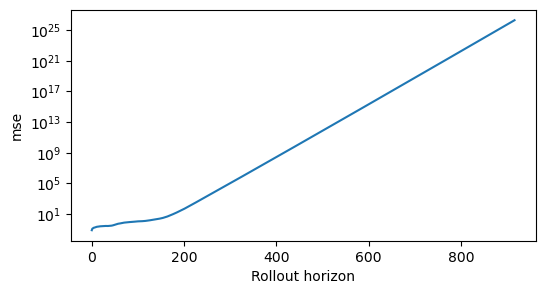

In [11]:
# --! plot MSE vs horizon

traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.xlabel('Rollout horizon')
    plt.ylabel('mse')
    plt.show()

datasaved = True
if datasaved:
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        save_mse_mean[:1, :disp_end, :1], save_mse_std[:1, :disp_end, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/global_mse{data_suffix}_seed_{seed}', savedata, delim=' ')

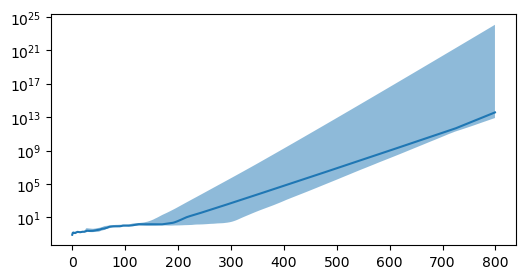

In [14]:
mseprocessed = False

if mseprocessed:
    length = 800
    mse_data = [
        util_data.read_datafile(
            f'{result_dir}/global_mse{data_suffix}_seed_{s}', length, delim=' ') for s in seeds]
    mse = torch.cat([mse[..., [2]] for mse in mse_data], dim=0)
    mse_median, _ = torch.median(mse, dim=0, keepdim=True)
    mse_percentile_10 = torch.quantile(mse, 0.1, dim=0, keepdim=True)
    mse_percentile_90 = torch.quantile(mse, 0.9, dim=0, keepdim=True)

    x = torch.arange(mse_median.shape[1]).reshape(1, -1, 1)

    plt.figure(figsize=(6,3))
    plt.plot(x[0, :, 0], mse_median[0, :, 0], linestyle='solid')
    plt.fill_between(x[0, :, 0], mse_percentile_10[0, :, 0], mse_percentile_90[0, :, 0], alpha=0.5)
    plt.yscale('log')
    plt.show()

    horizon = disp_end
    nmse = mse.shape[0]
    save_step = torch.arange(mse_median.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :horizon, :1],
        mse_median[:1, :horizon, :1],
        mse_percentile_10[:1, :horizon, :1], mse_percentile_90[:1, :horizon, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/global_mse_avg_{nmse}', savedata, delim=' ')